In [1]:
import sys
import os

# check deps
missing = []
try:
    import h5py
except ImportError:
    missing.append('h5py')
try:
    import tqdm
except ImportError:
    missing.append('tqdm')
if missing:
    print(f"pip install {' '.join(missing)}")
    raise SystemExit(1)

import numpy as np
import h5py
from tqdm import tqdm

sys.path.insert(0, '..')
from sim.env import DiffDriveEnv
from sim.expert import ExpertController

In [2]:
# --- config ---
N_TRAJECTORIES = 10000
MAX_STEPS      = 1000
SAVE_DIR       = '../data'
SUBSETS        = [1000, 2000, 5000, 10000]

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

env    = DiffDriveEnv()
expert = ExpertController(noise_std=0.001)

successful = []
failed     = []
total_attempts = 0

with tqdm(total=N_TRAJECTORIES, desc='Generating trajectories') as pbar:
    while len(successful) < N_TRAJECTORIES:
        total_attempts += 1
        obs = env.reset()

        ep_obs     = []
        ep_actions = []
        ep_xs, ep_ys, ep_thetas = [], [], []

        done = False
        for _ in range(MAX_STEPS):
            state  = env.get_state()
            ep_xs.append(state[0]); ep_ys.append(state[1])
            ep_thetas.append(np.arctan2(state[3], state[2]))
            action = expert.act(obs, state)
            ep_obs.append(obs.astype(np.float32))
            ep_actions.append(action.astype(np.float32))
            obs, done = env.step(action)
            if done:
                state = env.get_state()
                ep_xs.append(state[0]); ep_ys.append(state[1])
                ep_thetas.append(np.arctan2(state[3], state[2]))
                break

        if not done:
            failed.append({
                'xs': np.array(ep_xs), 'ys': np.array(ep_ys), 'thetas': np.array(ep_thetas),
                'x0': ep_xs[0], 'y0': ep_ys[0], 'theta0': ep_thetas[0],
                'xf': ep_xs[-1], 'yf': ep_ys[-1], 'thetaf': ep_thetas[-1],
            })
            continue

        T       = len(ep_obs)
        v_max   = 1.0
        vs      = np.array(ep_actions)[:, 0]
        dists   = np.array(ep_obs)[:, 0]
        rewards = (-1.0 - (1.0 - np.abs(vs) / v_max) * dists).astype(np.float32)
        rtg     = np.cumsum(rewards[::-1])[::-1].astype(np.float32)
        ts      = np.arange(T, dtype=np.int32)
        terms   = np.zeros(T, dtype=bool)
        terms[-1] = True

        successful.append({
            'obs':       np.array(ep_obs),
            'actions':   np.array(ep_actions),
            'rewards':   rewards,
            'rtg':       rtg,
            'timesteps': ts,
            'terminals': terms,
        })
        pbar.update(1)

lengths = [len(t['obs']) for t in successful]
print(f"\nDataset statistics:")
print(f"  Successful: {len(successful)} / {total_attempts} ({100*len(successful)/total_attempts:.1f}%)")
print(f"  Failed:     {len(failed)}")
print(f"  Trajectory lengths: min={min(lengths)}, mean={np.mean(lengths):.1f}, max={max(lengths)}")

Generating trajectories: 100%|██████████| 10000/10000 [00:10<00:00, 977.94it/s]


Dataset statistics:
  Successful: 10000 / 10000 (100.0%)
  Failed:     0
  Trajectory lengths: min=9, mean=178.0, max=679


In [4]:
if not failed:
    print("No failed trajectories.")
else:
    colors = cm.tab10(np.linspace(0, 1, len(failed)))
    fig, ax = plt.subplots(figsize=(8, 8))

    for color, t in zip(colors, failed):
        xs, ys, thetas = t['xs'], t['ys'], t['thetas']
        ax.plot(xs, ys, color=color, linewidth=1.8, alpha=0.9)

        dx = np.cos(thetas[0]) * 0.18
        dy = np.sin(thetas[0]) * 0.18
        ax.annotate('', xy=(xs[0] + dx, ys[0] + dy), xytext=(xs[0], ys[0]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.8))
        ax.plot(xs[0],  ys[0],  'o', color=color, markersize=7, zorder=3)
        ax.plot(xs[-1], ys[-1], 'x', color=color, markersize=11, markeredgewidth=2.5, zorder=4)
        dist_f = np.sqrt(t['xf']**2 + t['yf']**2)
        ax.text(xs[0] + 0.1, ys[0] + 0.1,
                f"x0=({t['x0']:.2f},{t['y0']:.2f})\nθ0={t['theta0']:.2f}\ndist_f={dist_f:.3f}",
                color=color, fontsize=7)

    ax.plot(0, 0, 'k*', markersize=18, zorder=5)
    ax.add_patch(plt.Circle((0, 0), 0.05, color='black', fill=False, linestyle='--', linewidth=1))
    ax.set_xlim(-3.5, 3.5)
    ax.set_ylim(-3.5, 3.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(f'Failed trajectories — {len(failed)}\n● start  → heading  ✕ end  ★ goal', fontsize=12)
    plt.tight_layout()
    plt.show()

No failed trajectories.


min=9  p25=137  median=169  mean=178.0  p75=205  max=679


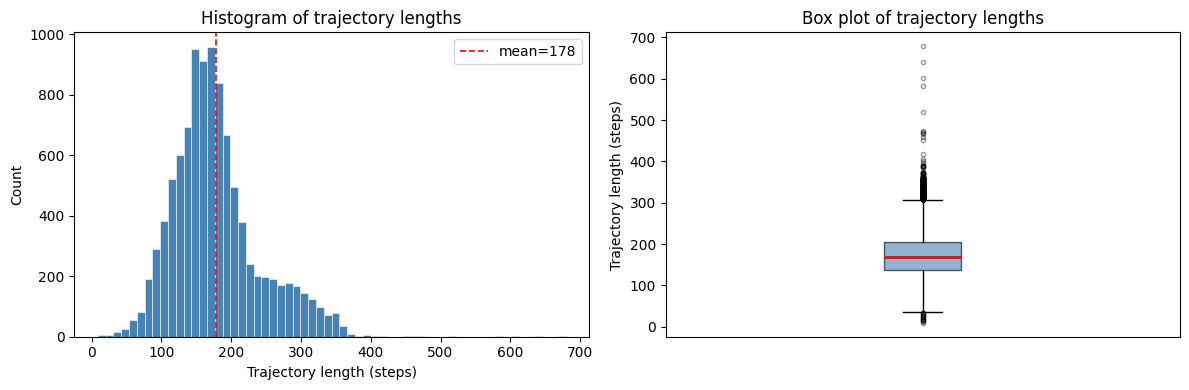

In [7]:
lengths = np.array([len(t['obs']) for t in successful])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(lengths, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.axvline(lengths.mean(), color='red', linestyle='--', linewidth=1.2, label=f'mean={lengths.mean():.0f}')
ax1.set_xlabel('Trajectory length (steps)')
ax1.set_ylabel('Count')
ax1.set_title('Histogram of trajectory lengths')
ax1.legend()

ax2.boxplot(lengths, vert=True, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.6),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax2.set_ylabel('Trajectory length (steps)')
ax2.set_title('Box plot of trajectory lengths')
ax2.set_xticks([])

print(f'min={lengths.min()}  p25={np.percentile(lengths,25):.0f}  '
      f'median={np.median(lengths):.0f}  mean={lengths.mean():.1f}  '
      f'p75={np.percentile(lengths,75):.0f}  max={lengths.max()}')

plt.tight_layout()
plt.show()

In [5]:
def save_hdf5(trajs, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    lens = [len(t['obs']) for t in trajs]
    with h5py.File(path, 'w') as f:
        for i, t in enumerate(trajs):
            grp = f.create_group(f'trajectory_{i}')
            for key, val in t.items():
                grp.create_dataset(key, data=val)
        meta = f.create_group('metadata')
        meta.create_dataset('n_trajectories', data=len(trajs))
        meta.create_dataset('mean_length',    data=float(np.mean(lens)))
        meta.create_dataset('min_length',     data=int(min(lens)))
        meta.create_dataset('max_length',     data=int(max(lens)))

os.makedirs(SAVE_DIR, exist_ok=True)

for k in SUBSETS:
    if k > len(successful):
        print(f'  skip dataset_{k//1000}k.h5 — not enough trajectories')
        continue
    path = f'{SAVE_DIR}/dataset_{k//1000}k.h5'
    print(f'Saving {os.path.basename(path)} ...', end=' ', flush=True)
    save_hdf5(successful[:k], path)
    print('done')

Saving dataset_1k.h5 ... done
Saving dataset_2k.h5 ... done
Saving dataset_5k.h5 ... done
Saving dataset_10k.h5 ... done


In [6]:
# --- verify: read back one trajectory ---
path = f'{SAVE_DIR}/dataset_{SUBSETS[0]//1000}k.h5'
with h5py.File(path, 'r') as f:
    t0 = f['trajectory_0']
    print('trajectory_0 keys:', list(t0.keys()))
    for key in t0:
        arr = t0[key][:]
        print(f'  {key}: shape={arr.shape}, dtype={arr.dtype}')
    print('metadata:')
    for key in f['metadata']:
        print(f'  {key}: {f["metadata"][key][()]}')

trajectory_0 keys: ['actions', 'obs', 'rewards', 'rtg', 'terminals', 'timesteps']
  actions: shape=(142, 2), dtype=float32
  obs: shape=(142, 3), dtype=float32
  rewards: shape=(142,), dtype=float32
  rtg: shape=(142,), dtype=float32
  terminals: shape=(142,), dtype=bool
  timesteps: shape=(142,), dtype=int32
metadata:
  max_length: 519
  mean_length: 178.671
  min_length: 26
  n_trajectories: 1000
